# Verilere bir göz atalım!

Bu bölümde, Kaggle'dan alınan şu veri setiyle çalışacağız: https://www.kaggle.com/datasets/saurabhbagchi/dish-network-hackathon?select=Train_Dataset.csv

In [ ]:
import pandas as pd
pd.set_option('display.max_columns', None)
import numpy as np

data = pd.read_csv("data/Train_Dataset.csv")

In [ ]:
data.head()

In [ ]:
X = data.drop(columns=["Default", "ID"])
y = data.Default

In [ ]:
y.value_counts(normalize = True)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
X_train.dtypes

In [ ]:
# Maalesef burada bir hata alıyoruz!
X_train["Client_Income"].astype(float)

In [ ]:
col_to_fix = ["Score_Source_3",
              "Client_Income",
              "Credit_Amount",
              "Loan_Annuity",
              "Age_Days",
              "Employed_Days",
              "Registration_Days",
              "ID_Days",
              "Population_Region_Relative"
             ]

# Pipeline’ı oluşturma ve veri tipini düzeltme!

In [ ]:
import string

print(string.punctuation)
print(string.ascii_letters)

In [ ]:
string.punctuation.replace(".", "") + string.ascii_letters

In [ ]:
def clean_df(X):

    def clean_value(value):
        unwanted_char = string.punctuation.replace(".", "") + string.ascii_letters
        for tag in unwanted_char:
            value = value.replace(tag, "")
        value = np.nan if not value else value
        return float(value)

    X = pd.DataFrame(X)
    X = X.astype(str).map(clean_value)
    return X


In [ ]:
from sklearn.pipeline import Pipeline, FunctionTransformer
from sklearn.compose import ColumnTransformer, make_column_selector

In [ ]:
cleaner = FunctionTransformer(clean_df)

type_cleaner = ColumnTransformer(
    [("type_cleaner", cleaner, col_to_fix)],
    remainder="passthrough"
    ).set_output(transform = "pandas")

In [ ]:
type_cleaner.fit_transform(X_train)

In [ ]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

In [ ]:
num_preproc = Pipeline([
    ("num_imputer", SimpleImputer(strategy="constant", fill_value=0.)),
    ("scaler", StandardScaler())
])

In [ ]:
cat_preproc = Pipeline([
    ("cat_imputer", SimpleImputer(strategy="constant", fill_value="Missing")),
    ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

In [ ]:
preproc = ColumnTransformer([
    ("num_tr", num_preproc, make_column_selector(dtype_include=["float64", "int64"])),
    ("cat_tr", cat_preproc, make_column_selector(dtype_include=["object"]))
])

In [ ]:
clean_preproc = Pipeline([
    ("cleaner", type_cleaner),
    ("preprocessing", preproc)])

In [ ]:
from sklearn.linear_model import LogisticRegression

pipe = Pipeline([
    ("clean_preproc", clean_preproc),
    ("classifier", LogisticRegression(max_iter=1000))
])

pipe

In [ ]:
from sklearn.model_selection import cross_val_score

In [ ]:
cross_val_score(pipe, X_train, y_train).mean()

# Bir dakika, işleri doğru mu yapıyoruz?

## Cross-validation yaparken dikkatli olmamız gerekiyor!


Dengesiz dataset’lerle 🌓 çalışırken, **Stratified K-Fold Cross-Validation** ile kendimizi donatalım! 🛡️🔄

Peki neden? 🤔

1. **Standart K-Fold** 🔄:  
   Bazı fold’larda azınlık sınıfını tamamen dışarıda bırakabilir 😨!  
   Bu da model değerlendirmesinin daha az güvenilir olmasına yol açar. 😢

2. **Stratified K-Fold** 🔀:  
   Her fold’un ⚙️ çoğunluk ve azınlık sınıflarından **uygun oranlarda** içermesini sağlar. 🎉

3. **Güvenilir Değerlendirme** 🎯:  
   Gerçek dünya performansını 🌍 daha iyi temsil eder.  
   Her iki sınıfı da dengede tutar! 🤹‍♂️

4. **Daha İyi Model Ayarı** 🚀:  
   Modelinizin azınlık sınıfını nasıl ele aldığını daha net görerek,  
   parametreleri daha bilinçli şekilde optimize etmenizi sağlar! 🕵️‍♀️

In [ ]:
from sklearn.model_selection import StratifiedKFold
cv = StratifiedKFold(n_splits=5)

cross_val_score(pipe, X_train, y_train, cv=cv).mean()

Bir dakika… Bu, öncekiyle **aynı sonuç** değil mi?

Gel, birlikte scikit-learn dokümantasyonunda `cross_validate()` fonksiyonuna bakalım ve özellikle `cv` parametresini inceleyelim.

<details>
  <summary><strong>Açıklama</strong></summary>

  Görünen o ki, scikit-learn varsayılan olarak **`StratifiedKFold`** kullanıyor.  
  Yani `cv=None` ya da `cv=k` (burada `k` istediğimiz fold sayısı) belirttiğimizde, classifier kullanılıyorsa stratification **otomatik olarak** uygulanıyor.

</details>

## Accuracy ile ilgili sorun nedir?

Dengesiz dataset’lerde 🌓, **precision-recall AUC** 📈 kraldır! 🤴

Neden mi? 🤔

- **Accuracy** 🎯, dengesiz dataset’lerde yanıltıcı olabilir. 😱

- **Yüksek recall**? Harika, ama **false positive**’lere dikkat! 🚨

- **Precision-Recall AUC**, farklı threshold’lar boyunca hem precision hem recall’u birlikte değerlendirir. 🌟  
  Eğri altındaki alan ne kadar büyükse = model o kadar iyi! 💪

- Tek bir sayıyla özet almak için sklearn’de **`average_precision_score`** 🛠️ kullanın. 🧮

Hadi buna bir göz atalım: https://scikit-learn.org/stable/auto_examples/model_selection/plot_precision_recall.html#sphx-glr-auto-examples-model-selection-plot-precision-recall-py

In [ ]:
cv = StratifiedKFold(n_splits=5)
cross_val_score(pipe, X_train, y_train, cv=cv, scoring="average_precision").mean()

In [ ]:
pipe.fit(X_train, y_train)

In [ ]:
X_test.head()

In [ ]:
from sklearn.metrics import PrecisionRecallDisplay, precision_recall_curve

In [ ]:
y_pred_prob = pipe.predict_proba(X_test)[:,1]

precision, recall, _ = precision_recall_curve(y_test, y_pred_prob)
disp = PrecisionRecallDisplay(precision=precision, recall=recall)
disp.plot()

## Daha karmaşık bir model deneyelim

In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
pipe = Pipeline([
    ("cleaner", type_cleaner),
    ("preprocessing", preproc),
    ("classifier", RandomForestClassifier())
])

In [ ]:
cv = StratifiedKFold(n_splits=5)
cross_val_score(pipe, X_train, y_train, cv=cv, scoring="average_precision").mean()

In [ ]:
pipe.fit(X_train, y_train)
y_pred_prob = pipe.predict_proba(X_test)[:,1]

precision, recall, _ = precision_recall_curve(y_test, y_pred_prob)
disp = PrecisionRecallDisplay(precision=precision, recall=recall)
disp.plot()

In [ ]:
y_pred_prob

## Sınıf dengesizliğini hesaba katalım

In [ ]:
pipe = Pipeline([
    ("cleaner", type_cleaner),
    ("preprocessing", preproc),
    ("classifier", RandomForestClassifier(class_weight="balanced"))
])

In [ ]:
cv = StratifiedKFold(n_splits=5)
cross_val_score(pipe, X_train, y_train, cv=cv, scoring="average_precision").mean()

In [ ]:
pipe.fit(X_train, y_train)
y_pred_prob = pipe.predict_proba(X_test)[:,1]


precision, recall, _ = precision_recall_curve(y_test, y_pred_prob)
disp = PrecisionRecallDisplay(precision=precision, recall=recall)
disp.plot()

# Model Kalibrasyonu

Şunu bir hayal et: Olasılıklar üreten harika bir model 🌟 geliştirdin. Sen mutlusun, modelin mutlu, ama DUR! Bu olasılıklar gerçekten güvenilir mi? 🤔

🎺 Sahneye çıkıyor: Model Calibration! 🎺

İşte neden bunun, model dondurmanın 🍨 üzerindeki vişne 🍒 gibi olduğunu açıklayan sebepler:

1. Güvenilir Olasılıklar 📊: Modelin yağmur olasılığının %80 olduğunu söylüyorsa ☔, gerçekten de yaklaşık zamanın %80’inde yağmur yağmalıdır! Calibration, çıktı olarak üretilen olasılıkların olayların gerçek gerçekleşme ihtimalini yansıtmasını sağlar.

2. Bilinçli Kararlar 💡: Calibrated olasılıklar sayesinde daha akıllı kararlar verebilirsin! Bu, macerana çıkarken ne kadar dragon repellent 🐲 taşıman gerektiğini tam olarak bilmeye benzer.

3. Model Karşılaştırması 🤺: İki model girer, bir model çıkar! Modelleri karşılaştırırken, iyi calibrated edilmiş olasılıklar, tahminlerin Excalibur 🗡️’unu kullanabilecek gerçek kahramanı 🦸 seçmene yardımcı olur!

4. Daha İyi Risk Yönetimi 💼: Finans, sağlık veya riskin yüksek olduğu herhangi bir alanda karar vermek, iksirlerle jonglörlük yapmak 🧪 gibidir. Calibrated olasılıklar, iksir karışımını tam kararında tutar!

5. Özel Thresholds 🚥: Her savaş aynı şekilde verilmez! Bazen stratejini değiştirmen gerekir. Calibrated olasılıklar, hedefinin gerektirdiği şekilde precision veya recall için optimize edebilmen adına özel thresholds belirlemene olanak tanır.

Şuna bir göz atalım: [https://scikit-learn.org/stable/modules/calibration.html#calibration](https://scikit-learn.org/stable/modules/calibration.html#calibration)


In [ ]:
from sklearn.calibration import CalibratedClassifierCV, CalibrationDisplay, calibration_curve

In [ ]:
prob_true, prob_pred = calibration_curve(y_test, y_pred_prob, n_bins=10)

disp = CalibrationDisplay(prob_true, prob_pred, y_pred_prob)
disp.plot()

In [ ]:
calibrated_clf = CalibratedClassifierCV(pipe, cv=cv)
calibrated_clf.fit(X_train, y_train)

In [ ]:
y_pred_prob = calibrated_clf.predict_proba(X_test)[:,1]

prob_true, prob_pred = calibration_curve(y_test, y_pred_prob, n_bins=10)

disp = CalibrationDisplay(prob_true, prob_pred, y_pred_prob)
disp.plot()

In [ ]:
# Not: Bu işlemin tamamlanması oldukça uzun sürebilir!
cv = StratifiedKFold(n_splits=5)
cross_val_score(calibrated_clf, X_train, y_train, cv=cv, scoring="average_precision").mean()

# Sonraki Adımlar

Calibrated bir modelimiz var, ancak işimiz henüz bitmedi! Eğer performanslardan memnun değilsek şunları uygulayabiliriz:

-Parameter Tuning (Grid Search)

-Daha da gelişmiş modeller denemek

-Oversampling veya Undersampling uygulamak

Son seçeneğe hızlıca bir göz atalım; bunun için Imbalanced-Learn library kullanacağız.

In [ ]:
#!pip install imbalanced-learn

In [ ]:
X_train_preproc = clean_preproc.fit_transform(X_train)

In [ ]:
print(X_train_preproc.shape)
print(y_train.value_counts())

## Aşırı örnekleme - SMOTE

SMOTE, azınlık sınıfını güçlendirmek için yeni, sentetik örnekler oluşturan bir sanatçı gibidir. Bunu, mevcut azınlık örnekleri arasında interpolation yaparak gerçekleştirir. Amaç, azınlık sınıfını daha büyük hale getirmek ve böylece model için daha anlamlı olmasını sağlamaktır. Ancak dikkatli olun! SMOTE, bazen orijinal örneklerden çok uzak sentetik örnekler üreterek gürültü oluşturabilir.

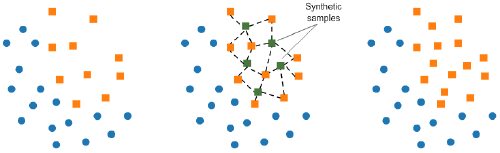

In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_preproc, y_train)

print(X_train_res.shape)
print(y_train_res.shape)
y_train_res.value_counts()

## Alt örnekleme - Rastgele Alt Örnekleyici

RUS’u, veri setini dengelemek için çoğunluk sınıfından bazı örnekleri rastgele atan bir atık bertaraf ünitesi gibi hayal et. Bunu yaparak modelin azınlık sınıfına daha fazla odaklanmasını sağlar. Ancak veri attığı için, faydalı bilgileri de gözden çıkarabilir. Bu yüzden RUS’u dikkatli kullan!

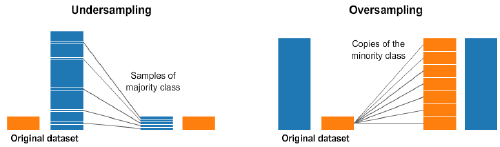

In [ ]:
from imblearn.under_sampling import RandomUnderSampler

rus = RandomUnderSampler(random_state=42)
X_train_res, y_train_res = rus.fit_resample(X_train_preproc, y_train)

print(X_train_res.shape)
print(y_train_res.shape)
y_train_res.value_counts()


## Alt örnekleme - Tomek Link

Tomek Links, birbirine yakın çoğunluk ve azınlık sınıfı örnek çiftlerini (bir ‘link’ oluşturarak) kendine çeken bir mıknatıs gibi davranır. Eğer bir çoğunluk sınıfı örneği bir Tomek Link oluşturursa, bu örnek kaldırılır ve sınıflar arasındaki borderline’ın temizlenmesine yardımcı olunur. Bu ‘borderline’ çoğunluk örneklerinin kaldırılması, modelin çoğunluk sınıfına karşı daha az biased olmasını sağlayabilir. Ancak, dengesizlik çok şiddetliyse bu yöntem yeterli olmayabilir.

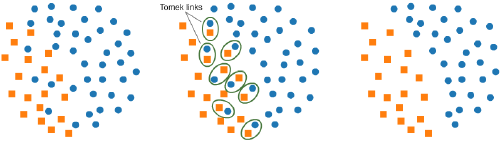

In [ ]:
from imblearn.under_sampling import TomekLinks

tl = TomekLinks()
X_train_res, y_train_res = tl.fit_resample(X_train_preproc, y_train)

print(X_train_res.shape)
print(y_train_res.shape)
y_train_res.value_counts()
